# Unit 3 Day 5 – Visualizing Categorical Variables


In [2]:
from datascience import * # datascience has plotting features built in
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")

import warnings
warnings.filterwarnings('ignore')
#Table.interactive_plots() 

## Bar Charts

Bar charts are helpful for visualizing the relationship between a categorical variable and a numerical variable, or for visualizing the distribution of a categorical variable. For example, we can visualize the number of cookies we have of each type (at our imaginary cookie store).

In [2]:
cookies = Table()
cookies = cookies.with_columns(
    "Cookie", make_array("chocolate chip", "red velvet","oatmeal raisin",  "sugar cookies", "peanut butter"),
    "Count", make_array(15, 15, 10, 10, 5)
)
cookies

Cookie,Count
chocolate chip,15
red velvet,15
oatmeal raisin,10
sugar cookies,10
peanut butter,5


In [ ]:
# Create a horizontal bar chart of the cookies

### Example 1: Top 10 Songs on Spotify

The streaming service Spotify has a lot of [data](https://spotifycharts.com/regional) we can work with. 

While the spotify song charts are nice sometimes we like to gather additional data to spice up our analysis such as in this case the year a song was released or the key of the song. Luckily there is publicly available data on [kaggle](https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023?resource=download) that provides just this. However, since we're working with Kaggle data it's always important to consider the limitations (i.e. the dataset contains 952 of the most famous songs from 2023, how did the author of the dataset define famous?
)

In [ ]:
# Select the track name and streams columns from a table and store them in the top_10_simple Table
top_10_simple = Table.read_table('data/spotify-2023-top-10.csv').select("track_name", "streams")
top_10_simple

track_name,streams
Blinding Lights,3703895074
Shape of You,3562543890
Someone You Loved,2887241814
Dance Monkey,2864791672
Sunflower - Spider-Man: Into the Spider-Verse,2808096550
One Dance,2713922350
STAY (with Justin Bieber),2665343922
Believer,2594040133
Closer,2591224264
Starboy,2565529693


In [ ]:
 # Create a bar chart of streams for each of the songs in `top_10_simple`

In the previous example, I gave you a simplified table with only two columns. What happens if we have more than two columns in a table?

In [ ]:
# Load the full top 10 table
top_10 = Table.read_table('data/spotify-2023-top-10.csv')
top_10

If we try to use the same `.barh()` format from above, our cell will cause an error.

In [ ]:
top_10.barh('track_name') # This code causes an error

<div class="alert alert-warning">
  
  <div>
    <h1>🤔 What was the error - copy and paste it here. </h1>
  </div>
  <p>
    Why do you think this error is happening?
  </p>
</div>

In [ ]:
# Create a bar chart of streams for each of the songs in `top_10`

## `sort`

Sometimes, our bar charts are still hard to understand intuitively because they are in an order that doesn't make sense (or doesn't provide us with much information):

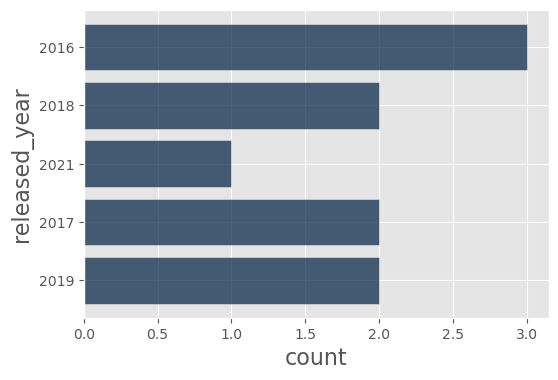

In [14]:
release_year = top_10.group("released_year").sample(5, with_replacement=False)
release_year.barh('released_year', 'count')

When there is some inherent order to the categories (e.g. the top songs sorted by number of streams or year of release), we can sort the rows first before calling `.barh()` to ensure that the bars in the bar chart are sorted. 

To sort rows in a table, we will use `tbl.sort(column)`. This function takes the argument `column`, which is the name of the column in the table to sort by, and an optional argument `descending` which can either be `True` or `False`, depending on whether we want to sort the table in ascending or descending order.

In [1]:
# Recreate the bar chart, this time in an order that makes sense.

## `take`

Now, we are going to load in the full table of the Spotify Top 200.

In [ ]:
streams = Table.read_table('data/regional-global-daily-latest.csv')
streams

In [ ]:
# Visualize the track names by streams. 

<div class="alert alert-warning">
  
  <div>
    <h1>🤔 This is unwieldly. </h1>
  </div>
  <p>
    What could we do instead?
  </p>
</div>

In [ ]:
# Create an alternative table to present useful information

Now, when we generate our bar chart, we are able to visualize all ten songs very easily.

In [ ]:
# Generate a bar chart of streams by song

In [2]:
# Create a table, streams_top_15 which contains the top 15 most streamed songs, generate a bar chart showing how many streams each artist has.

In [3]:
# Create a bar chart showing the artists with the number of streams they have

Notice how the artist The Weeknd has multiple songs in the top 15, but their total streams are not counted together? We will learn how to consolidate all of the songs by a single artist soon...

## Grouping Bars

When two numerical variables have the same scale or magnitude, it is sometimes useful to visualize these variables together. For example, we have a column in `top_10` called `in_spotify_charts`, which is the current spot in the spotify charts of a song. We also have a column `in_apple_charts`, which is the current rank on the apple charts of a song.

In [ ]:
top_10.select('in_spotify_charts', 'track_name', 'in_apple_charts')

In [ ]:
top_10.barh('track_name', 'in_spotify_charts')

In [ ]:
top_10.barh('track_name', 'in_apple_charts')

Since both of these variables have the same scale, we can easily visualize them togther in one bar chart. To do this, we need to make sure our table only has the three columns `in_spotify_charts`, `rank` and `in_apple_charts`. Then we can call `.barh()` to make an overlaid/grouped bar chart.

In [ ]:
... # Create a grouped bar chart showing `in_spotify_charts` and `in_apple_charts` for each song

If we prefer to visualize these variables separately, we can eliminate the overlay by setting the optional argument `overlay` to `False`.

In [ ]:
... # Create two separate bar charts showing `in_spotify_charts` and `in_apple_charts` for each song
# (Hint: set `overlay=False`)